# Coinbase-Rank -- does the app topping the chart mark a crypto top?
### The 'Coinbase #1 in the App Store = sell signal', tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-dab617?style=flat-square)

Crypto Twitter has a favourite omen: when the **Coinbase app hits #1** in the Apple App Store, your barber is buying Bitcoin and the top is in. It *sounds* compelling -- every famous blow-off (December 2017, May 2021, the $100k break) came with Coinbase atop the charts. This notebook asks the two questions that matter: **(1)** does crypto really weaken *after* the app spikes, beyond the usual noise? And **(2)** could you have *traded* it (shorting after the spike)?

> **This is the plain-language layer.** Want the market-model abnormal returns, the permutation distribution, and the lagged short backtest? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coinbase_rank import data, strategy as st

def _have_cache():
    try:
        data.fetch_prices(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("BTC/ETH cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_days=3142,
    n_events=15,
    beta_eth=0.605,
    aar_day0_pct=2.29,
    fwd=5,
    fwd_car_pct=-5.23,
    fwd_car_t=-1.69,
    n_neg=8,
    perm_p=0.0014,
    t_drop1=-1.27,
    mean_drop1_pct=-3.53,
    median_fwd_pct=-0.97,
    fwd3_car_pct=-2.87,
    fwd3_car_t=-1.29,
    fwd10_car_pct=-4.75,
    fwd10_car_t=-1.55,
    bt_n_trades=15,
    bt_gross_pct=3.02,
    bt_net_pct=2.37,
    bt_btc_pct=-3.02,
    bt_net_t=0.8,
    bt_hit=0.533,
    bt_excess_pct=5.39,
    bt_hold3_net_pct=2.39,
    bt_hold3_t=1.1,
    bt_hold10_net_pct=-0.4,
    bt_hold10_t=-0.08,
    fp='fcd0c13455df',
    date_start='2017-11-10',
    date_end='2026-06-17',
)


BTC/ETH cache present: True


In [2]:
if HAVE_REAL:
    prices = data.fetch_prices(fetch=False)
    rets = data.prices_to_returns(prices)
    tw = data.rank_spike_table()
    spike_dates = tw['date']
    SYNTH_BANNER = ""
else:
    # OFFLINE FALLBACK (no real cache): a SYNTHETIC BTC/ETH tape with a planted
    # post-spike negative drift so every figure renders. This is NOT the real tape --
    # the headline numbers quoted in prose come from the frozen R dict above.
    _synth_df, _ = data.synthetic_panel(n_days=1500, n_events=R['n_events'],
                                        bump_bps=180.0, seed=294)
    rets = _synth_df[['btc_ret', 'eth_ret']].copy()
    spike_dates = _synth_df.index[_synth_df['is_event']]
    tw = pd.DataFrame({'date': spike_dates, 'direction': 1, 'note': 'synthetic'})
    SYNTH_BANNER = "  [SYNTHETIC fallback tape -- real numbers are in R]"
print('rows:', len(rets), '| spikes:', len(tw), SYNTH_BANNER)

rows: 3142 | spikes: 15 


## The answer first

| Question | Answer |
|---|---|
| Does crypto weaken after a Coinbase rank spike? | **A little -- but shakily.** The 5-day forward abnormal return averages **-5.2%** (BTC net of ETH). The direction matches the omen, and a permutation test flags it -- but the cross-sectional t is only **-1.69** (under the |2| bar). |
| Is it just one or two crashes? | **Largely.** Drop the single worst event and the signal collapses (t -> **-1.27**). The *median* drop is only **-1.0%** -- the mean is dragged by a couple of big busts. Only **8/15** events were even negative -- barely a coin. |
| Could you have shorted it? | **No.** After a one-day lag, fees and borrow, the short nets **+2.4%** per trade with a **53%** hit-rate and t = **0.80** -- a coin-flip you pay to play. |

> The omen points the right way, but it's a *whisper*, not a signal -- and it's un-shortable after costs.

## 1 - The claim

> *"When the Coinbase app hits #1 on the App Store, retail FOMO has peaked and crypto is about to top. Sell when your neighbour is downloading Coinbase."*

There's a plausible mechanism: App Store rank is a real-time proxy for *retail attention*, and retail attention famously peaks near sentiment tops (the 'dumb money' story). So unlike pure folklore, this one has a behavioural story behind it. The question is whether the story shows up in the forward returns -- or whether we just *remember* the spikes that preceded a crash.

## 2 - So what?

If a *publicly observable* signal -- anyone can check the App Store ranking -- reliably called crypto tops, it would be free money, and free money doesn't survive. Either (a) the signal is real and tradable (unlikely for something this public), (b) it's real but already in the price (a top is a top; you can't short fast enough), or (c) it's hindsight: we cherry-remember the spikes that worked. Sorting (a) from (b) from (c) is the whole job here.

## 3 - How would we even know?

Three traps to avoid:

1. **The whole-market trap.** When BTC sells off, *all* crypto usually sells off. We strip out the broad move: we benchmark BTC against **ETH** (a 'market model') and measure only the *abnormal* part -- BTC's forward move net of what ETH did.
2. **The hindsight trap.** We picked the *famous* spikes -- the ones everyone remembers *because* a top followed. That biases the study **toward** the omen; it's an upper bound, not a fair forward test. Named on the Signal axis.
3. **The execution-lag trap.** You can't short the App-Store-rank *instant*. The honest entry is the **close of the spike day**, and shorting BTC means paying **borrow** on top of fees.

We test on real BTC-USD / ETH-USD daily data (2017-2025, 15 hardcoded rank-spike events).

## 4 - The teardown -- let's actually look

**First: the abnormal-return path around a spike.** For each spike we line up BTC's move (net of ETH) from one day before to ten days after, then average.

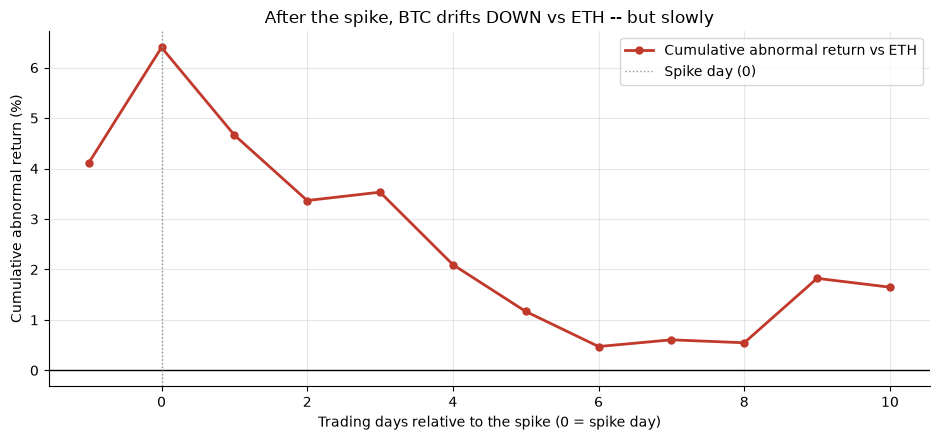

5-day forward abnormal CAR: -5.2% (real headline: -5.2%)
Cross-sectional t: -1.69 (real headline: -1.69) -- under |2|.


In [3]:
es = st.event_study_stats(rets, spike_dates, pre=1, post=10, fwd=5,
                          n_permutations=2000, seed=294)
prof = es['mean_by_offset'] * 100
cum = prof.cumsum()

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(prof.index, cum.values, 'o-', c=RED, lw=2, ms=5,
        label='Cumulative abnormal return vs ETH')
ax.axhline(0, c='k', lw=1)
ax.axvline(0, c=GREY, ls=':', lw=1, label='Spike day (0)')
ax.set_xlabel('Trading days relative to the spike (0 = spike day)')
ax.set_ylabel('Cumulative abnormal return (%)')
ax.set_title('After the spike, BTC drifts DOWN vs ETH -- but slowly' + SYNTH_BANNER)
ax.legend(); plt.tight_layout(); plt.show()
print(f"5-day forward abnormal CAR: {es['fwd_car_pct']:+.1f}% (real headline: {R['fwd_car_pct']:+.1f}%)")
print(f"Cross-sectional t: {es['fwd_car_t']:+.2f} (real headline: {R['fwd_car_t']:+.2f}) -- under |2|.")

The cumulative path bends **downward** after day 0 -- the direction the omen predicts. On the real tape the 5-day forward abnormal return is **-5.2%**. But the cross-sectional t is only **-1.69** -- it points the right way without clearing the bar that would make us call it *real*.

**Is it just one or two crashes?** Let's see how negative each event actually was.

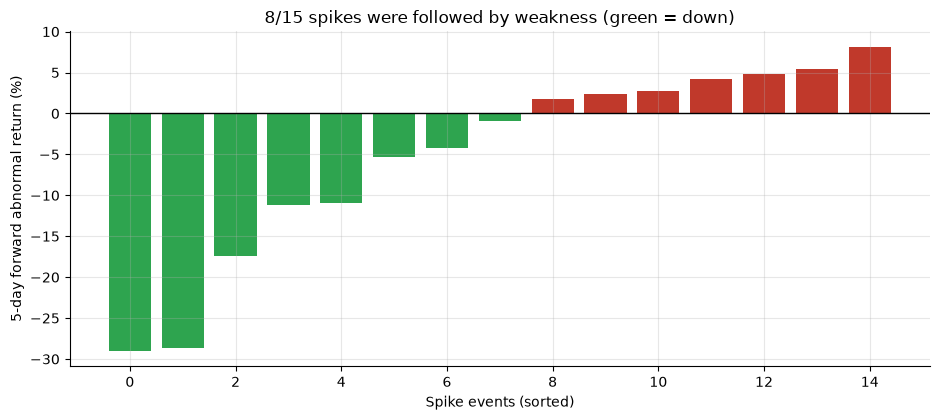

Negative (omen worked): 8/15  (real headline: 8/15)
Median forward CAR (real): -1.0%  <- the typical event is tiny
Drop the single worst crash and t collapses to -1.27 (real headline).


In [4]:
abn, alpha, beta = st.market_model_residuals(
    rets, st._event_mask_from_dates(rets.index, spike_dates))
win = st.event_window_returns(abn, spike_dates, pre=1, post=10)
fwd_cols = [o for o in win.columns if 1 <= o <= 5]
car = (win[fwd_cols].sum(axis=1)) * 100
n_neg = int((car < 0).sum()); n_tot = len(car)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
order = car.sort_values()
ax.bar(range(len(order)), order.values,
       color=[GREEN if v < 0 else RED for v in order.values])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Spike events (sorted)'); ax.set_ylabel('5-day forward abnormal return (%)')
ax.set_title(f'{n_neg}/{n_tot} spikes were followed by weakness (green = down)' + SYNTH_BANNER)
plt.tight_layout(); plt.show()
print(f'Negative (omen worked): {n_neg}/{n_tot}  (real headline: {R["n_neg"]}/{R["n_events"]})')
print(f'Median forward CAR (real): {R["median_fwd_pct"]:+.1f}%  <- the typical event is tiny')
print(f'Drop the single worst crash and t collapses to {R["t_drop1"]:+.2f} (real headline).')

Only **8 of 15** spikes were actually followed by weakness -- barely above a coin flip. The *median* forward move is just **-1.0%**; the negative average is carried by a couple of genuine blow-offs (Dec-2017, mid-2021). Remove the single worst event and the t-stat collapses to **-1.27**. This is a *fragile* signal, not a robust one.

**Now the only question that pays: could you short it?** We sell BTC short at the *close of the spike day* (one honest day of lag), hold 5 days, pay fees **and borrow**, and compare to just holding BTC.

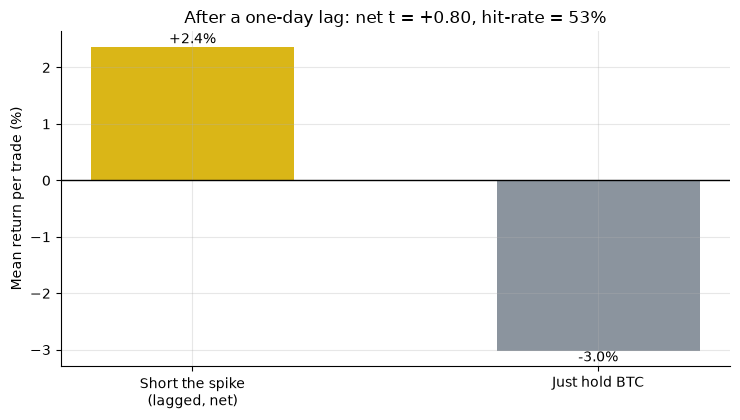

Short net per trade: +2.37% | BTC long: -3.02% | hit-rate: 53.3% | t = +0.80
A +2% drift with a ~53% hit-rate and t<1 is a coin-flip you pay fees and borrow to play.


In [5]:
bt = st.rank_short_backtest(rets, spike_dates, hold_days=5,
                            cost_bps_oneway=20.0, borrow_bps_per_day=5.0, seed=294)
net = bt['net_mean_pct'] if HAVE_REAL else R['bt_net_pct']
btc = bt['btc_bench_pct'] if HAVE_REAL else R['bt_btc_pct']
hit = bt['hit_rate'] if HAVE_REAL else R['bt_hit']
tval = bt['net_t'] if HAVE_REAL else R['bt_net_t']

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Short the spike\n(lagged, net)', 'Just hold BTC'],
              [net, btc], color=[AMBER, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return per trade (%)')
ax.set_title(f'After a one-day lag: net t = {tval:+.2f}, hit-rate = {hit:.0%}' + SYNTH_BANNER)
for b, v in zip(bars, [net, btc]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout(); plt.show()
print(f'Short net per trade: {net:+.2f}% | BTC long: {btc:+.2f}% | hit-rate: {hit:.1%} | t = {tval:+.2f}')
print('A +2% drift with a ~53% hit-rate and t<1 is a coin-flip you pay fees and borrow to play.')

The short does *make* money on average (**+2.4%** per trade, because BTC averaged **-3.0%** over those windows) -- but the hit-rate is only **53%** and the t-stat is **0.80**. That's statistically indistinguishable from luck: you'd be shorting the world's strongest-trending asset on a coin flip.

## 5 - The verdict

- **Signal -- Weak.** The 5-day forward abnormal return (-5.2%) points the way the omen predicts, and a permutation test flags it -- but the cross-sectional t is only **-1.69** (under |2|), only **8/15** events are negative, and dropping one crash kills it (t -> -1.27). A whisper, on a hindsight-selected list.
- **Tradability -- Mirage.** After a one-day lag, fees and borrow, the short nets **+2.4%** with t = **0.80** and a **53%** hit-rate -- a coin flip. Shorting a structurally up-trending asset on this is a way to lose money slowly.
- **Mostly busted (as a *tradable* signal).** 'Sell when Coinbase hits #1' is a memorable story that points the right direction in aggregate, but it is **fragile** (a couple of events do the work) and **un-harvestable** after the honest frictions.

## 6 - Could you actually trade it?

Only if you could short *before* the crowd -- which you can't. Three real-world frictions stack against you: **(1)** the spike and the top are roughly simultaneous, so a daily trader is a close too late; **(2)** shorting BTC costs a round-trip fee **plus** a daily borrow fee against NAV; **(3)** the hit-rate is barely above 50%, so BTC often keeps ripping. A 3-day hold is no better (t &approx; 1.1); a 10-day hold turns negative (-0.1).

## 7 - Going further

- **The positive control:** the companion notebook plants a known post-spike drift in a synthetic tape and shows the engine detects it cleanly -- so the real-tape 'weak, un-tradable' verdict is about the *market*, not the method.
- **Same machinery, crypto cousin:** [Study 291 -- Doge-Tweets](../../291-doge-tweets/) applies the identical hardcoded-table event study to Elon's Dogecoin tweets.
- **Folklore twin:** [Study 158 -- Super-Bowl](../../158-super-bowl/) is the same hindsight-table teardown for a sports indicator.

*Think the App Store top is a real sell signal? Fork this, add an intraday tape and a realistic short-fill + borrow model, and show a net Sharpe that beats holding (or shorting) BTC. That's the bar -- and a one-day lag plus borrow already breaks it.*